# Naive Bayes (TF-IDF) — MBTI Binary Dimensions

This notebook trains four binary Multinomial Naive Bayes classifiers (one per MBTI dimension) using TF-IDF vectorization.

## Overview

**Objective:** Predict each of the four MBTI dimensions independently:
- Introversion (I) vs. Extraversion (E)
- Intuition (N) vs. Sensing (S)  
- Thinking (T) vs. Feeling (F)
- Judging (J) vs. Perceiving (P)

**Why TF-IDF?**
- TF-IDF (Term Frequency-Inverse Document Frequency) weights words by their importance
- Reduces the influence of common words that appear in many documents
- Emphasizes distinctive words that are more characteristic of specific personality types
- Often outperforms simple Bag of Words for text classification

**TF-IDF vs. Bag of Words:**
- **BoW**: Raw frequency counts (how many times a word appears)
- **TF-IDF**: Weighted scores (balances frequency with rarity across documents)
- This notebook complements the BoW approach for performance comparison

## 1 - Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, precision_score, recall_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib

print("Packages imported successfully!")

Packages imported successfully!


## 2 - Load Data

Load the preprocessed MBTI dataset containing:
- **posts**: Aggregated text posts from each user
- **type**: 4-letter MBTI personality type

The flexible path search ensures compatibility across different development environments.

In [2]:
print("Loading data from CSV...")

current_dir = Path.cwd()
csv_path = None

# Search for 'preprocessed_data.csv' in current and parent folders
for parent in [current_dir] + list(current_dir.parents)[:3]:
    candidate = parent / 'data' / 'processed' / 'preprocessed_data.csv'
    if candidate.exists():
        csv_path = candidate
        break

# Check if csv_path was found
if csv_path is None:
    raise FileNotFoundError(f"Could not find 'preprocessed_data.csv' in current directory or parent folders")

print(f"Found CSV at: {csv_path}")

Loading data from CSV...
Found CSV at: c:\Users\Stijn\OneDrive - KU Leuven\UNIF\MASTER1\MACHINE LEARNING\ML_MBTI_project\data\processed\preprocessed_data.csv


In [3]:
# Read the CSV
df = pd.read_csv(csv_path)

print(f"Columns found: {df.columns.tolist()}")

text_col = 'posts' 
target_col = 'type'

# Sanity check to ensure these columns exist before proceeding
if text_col not in df.columns or target_col not in df.columns:
    raise ValueError(f"Error: Expected columns '{text_col}' and '{target_col}' but found {df.columns.tolist()}")

print(f"Using columns: Text='{text_col}', Target='{target_col}'")

# Remove rows where text or type is missing
df = df.dropna(subset=[text_col, target_col])
print(f"Data loaded successfully! Shape: {df.shape}")

Columns found: ['type', 'posts', 'num_posts', 'no. of. words', 'type_encoded']
Using columns: Text='posts', Target='type'
Data loaded successfully! Shape: (8462, 5)


## 3 - Vectorization (TF-IDF)

**TF-IDF (Term Frequency-Inverse Document Frequency):**

For each word in each document:
$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

where:
- **TF (Term Frequency)**: How often word $t$ appears in document $d$
  $$\text{TF}(t, d) = \frac{\text{count of } t \text{ in } d}{\text{total words in } d}$$

- **IDF (Inverse Document Frequency)**: How rare the word is across all documents
  $$\text{IDF}(t) = \log\left(\frac{\text{total documents}}{\text{documents containing } t}\right)$$

**Intuition:**
- Common words (appear in many documents) get low IDF scores
- Rare, distinctive words get high IDF scores  
- Words frequent in a document but rare overall get highest TF-IDF scores
- These distinctive words are most informative for classification

**Why TF-IDF for Personality Detection?**
- Different personality types may use distinctive vocabulary
- TF-IDF helps identify words characteristic of specific types
- Reduces noise from common words everyone uses
- Better captures unique linguistic patterns

**Parameters:**
- `max_features=2000`: Keep top 2000 most important features
- `stop_words='english'`: Remove common function words
- Output is sparse matrix (memory efficient for high-dimensional data)

In [4]:
print("Vectorizing text (TF-IDF)... This might take a minute...")

tfidf = TfidfVectorizer(max_features=2000, stop_words='english')

X = tfidf.fit_transform(df[text_col])
y = df[target_col].values

print(f"Data Ready! Features shape: {X.shape}")

Vectorizing text (TF-IDF)... This might take a minute...
Data Ready! Features shape: (8462, 2000)


## 4 - Train & Evaluate Models

### 4.1 Multinomial Naive Bayes Theory

**Probabilistic Foundation:**

Naive Bayes classifies by computing:
$$\hat{y} = \arg\max_y P(y) \prod_{i=1}^{n} P(x_i|y)$$

where:
- $P(y)$: Prior probability of class $y$ (from training data)
- $P(x_i|y)$: Likelihood of feature $x_i$ given class $y$
- "Naive" assumption: features are independent given the class

**For Text Classification:**
- Each word is treated as a feature
- Model learns word probability distributions for each class
- Classification = which class makes the observed words most probable

**Strengths:**
- Fast training and prediction (linear in number of features)
- Works well with high-dimensional sparse data
- Requires relatively small training data
- Provides probability estimates

**Limitations:**
- Independence assumption often violated in text (words are correlated)
- Can be oversensitive to feature distribution
- May struggle with class imbalance

### 4.2 Training Configuration

**Handling Class Imbalance:**
- MBTI dataset has significant class imbalance (e.g., more N than S types)
- `RandomOverSampler`: Randomly duplicates minority class samples
- Balances classes before training to prevent bias toward majority class
- Applied after train/test split on training data only

**Regularization (`alpha=5.0`):**
- Laplace (additive) smoothing prevents zero probabilities
- Formula: $P(x_i|y) = \frac{\text{count}(x_i, y) + \alpha}{\text{count}(y) + \alpha \times n_{features}}$
- Higher $\alpha$ = stronger smoothing = less overfitting
- We use 5.0 (vs. default 1.0) for better generalization

**Comprehensive Evaluation:**
- **Accuracy**: Proportion of correct predictions
- **Precision**: Of predicted positives, how many are correct
- **Recall**: Of actual positives, how many are found
- **F1-Score**: Harmonic mean of precision and recall (better for imbalanced data)
- **Cross-Validation Score**: Performance on multiple data splits (5-fold)
- **Overfitting Gap**: Difference between train and test accuracy

**Why Binary Classification per Dimension?**
1. MBTI traits are inherently binary
2. More interpretable (understand performance per trait)
3. Can analyze which dimensions are easier to predict
4. Often more accurate than single 16-class model
5. Allows independent prediction of each dimension

In [5]:
print("Starting Naive Bayes Training...")

dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
results = {}
results_detailed = {}
f1_scores = []

# Set a nice style for the plots
sns.set_style("whitegrid")

for trait1, trait2 in dimensions:
    print(f"\nProcessing {trait1} vs {trait2}")
    
    # Logic: If the label contains the second letter (e.g. 'E'), it's a 1. Else 0.
    y_binary = np.array([1 if trait2 in label else 0 for label in y])
    
    # Upsampling (Crucial for Naive Bayes)
    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X, y_binary)
    
    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(
        X_resampled, y_resampled, test_size=0.20, random_state=42
    )
    
    # Train with alpha tuning to prevent overfitting
    clf = MultinomialNB(alpha=5.0)
    clf.fit(X_train, y_train)
    
    # Evaluate on both train and test to detect overfitting
    train_preds = clf.predict(X_train)
    train_acc = accuracy_score(y_train, train_preds)
    
    test_preds = clf.predict(X_test)
    test_acc = accuracy_score(y_test, test_preds)
    
    # Calculate additional metrics
    current_f1 = f1_score(y_test, test_preds, average='macro')
    precision = precision_score(y_test, test_preds, average='macro', zero_division=0)
    recall = recall_score(y_test, test_preds, average='macro', zero_division=0)
    overfit_gap = train_acc - test_acc
    
    # Cross-validation score
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(clf, X_resampled, y_resampled, cv=cv, scoring='accuracy')
    cv_score = cv_scores.mean()
    
    conf_mat = confusion_matrix(y_test, test_preds)
    
    dim_name = f"{trait1}/{trait2}"
    results[dim_name] = test_acc
    f1_scores.append(current_f1)
    
    # Store detailed metrics
    results_detailed[dim_name] = {
        'model': clf,
        'accuracy': 100 * test_acc,
        'train_accuracy': 100 * train_acc,
        'f1_score': 100 * current_f1,
        'precision': 100 * precision,
        'recall': 100 * recall,
        'overfit_gap': 100 * overfit_gap,
        'cv_score': 100 * cv_score,
        'y_test': y_test,
        'y_pred': test_preds
    }
    
    print(f"   Train Accuracy: {train_acc:.2%}")
    print(f"   Test Accuracy:  {test_acc:.2%}")
    print(f"   F1-Score:       {current_f1:.2%}")
    print(f"   Precision:      {precision:.2%}")
    print(f"   Recall:         {recall:.2%}")
    print(f"   Difference:     {overfit_gap:.2%}")
    if overfit_gap > 0.05:
        print(f"   Possible overfitting detected!")
    print(f"   Macro F1-Score: {current_f1:.4f}")
    print(f"   Confusion Matrix:\n{conf_mat}")

# Summary statistics
total_accuracy = sum(results.values())
avg_accuracy = total_accuracy / len(results)
avg_f1 = sum(f1_scores) / len(f1_scores)
print(f"\nTotal Sum of Accuracies: {total_accuracy:.4f}")
print(f"Average Accuracy: {avg_accuracy:.2%}")
print(f"Average F1 Score: {avg_f1:.4f}")

Starting Naive Bayes Training...

Processing I vs E
   Train Accuracy: 73.00%
   Test Accuracy:  69.66%
   F1-Score:       69.52%
   Precision:      70.04%
   Recall:         69.66%
   Difference:     3.33%
   Macro F1-Score: 0.6952
   Confusion Matrix:
[[ 820  486]
 [ 307 1001]]

Processing N vs S
   Train Accuracy: 75.62%
   Test Accuracy:  73.58%
   F1-Score:       73.43%
   Precision:      74.45%
   Recall:         73.75%
   Difference:     2.05%
   Macro F1-Score: 0.7343
   Confusion Matrix:
[[ 963  523]
 [ 247 1181]]

Processing T vs F
   Train Accuracy: 76.14%
   Test Accuracy:  73.77%
   F1-Score:       73.63%
   Precision:      74.24%
   Recall:         73.77%
   Difference:     2.37%
   Macro F1-Score: 0.7363
   Confusion Matrix:
[[608 303]
 [175 736]]

Processing J vs P
   Train Accuracy: 68.72%
   Test Accuracy:  62.33%
   F1-Score:       62.33%
   Precision:      62.34%
   Recall:         62.34%
   Difference:     6.38%
   Possible overfitting detected!
   Macro F1-Score: 

## 5 - Visualize Results

Visual comparison of model performance across MBTI dimensions:
- Identifies which personality traits are most predictable from text
- Shows consistency (or variance) across different dimensions
- Helps diagnose potential issues (e.g., one dimension performing much worse)

Expected patterns:
- Some dimensions naturally easier to predict (e.g., I/E from posting frequency)
- N/S often challenging due to class imbalance and subtle linguistic differences

Generating Bar Graph...


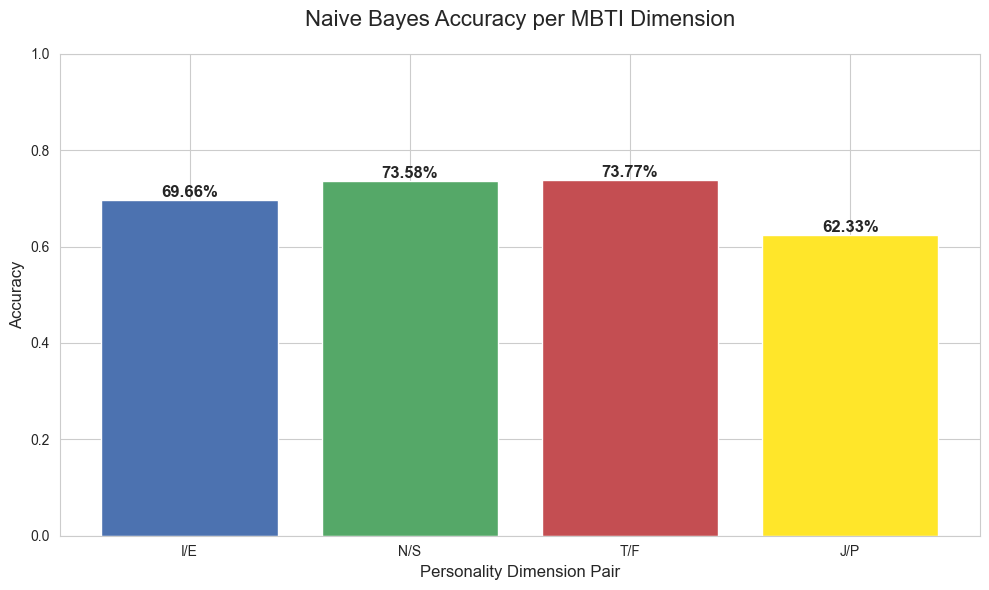

In [6]:
print("Generating Bar Graph...")

plt.figure(figsize=(10, 6))
keys = list(results.keys())
values = list(results.values())

# Create bars
bars = plt.bar(keys, values, color=['#4c72b0', '#55a868', '#c44e52', "#ffe62a"])

# Add title and labels
plt.title('Naive Bayes Accuracy per MBTI Dimension', fontsize=16, pad=20)
plt.xlabel('Personality Dimension Pair', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1.0)

# Add the percentage numbers on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height,
             f'{height:.2%}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 6 - Final Summary

In [7]:
print("\n" + "="*30)
print("FINAL RESULTS")
print("="*30)
for pair, score in results.items():
    print(f"{pair}: {score:.2%}")


FINAL RESULTS
I/E: 69.66%
N/S: 73.58%
T/F: 73.77%
J/P: 62.33%


## 7 - Save Models

Persist trained models and metrics for:
- Future predictions without retraining
- Model comparison across different approaches
- Deployment or integration with other systems

Saved data includes:
- Trained classifier for each dimension
- TF-IDF vectorizer (to transform new text consistently)
- Performance metrics for documentation
- Hyperparameters for reproducibility

In [8]:
print("Saving Naive Bayes (TF-IDF) models with comprehensive metrics...")

model_data = {
    'dimensions': list(results_detailed.keys()),
    'models': {dim: results_detailed[dim]['model'] for dim in results_detailed},
    'accuracies': {dim: results_detailed[dim]['accuracy'] / 100 for dim in results_detailed},
    # Comprehensive metrics
    'metrics': {dim: {
        'accuracy': results_detailed[dim]['accuracy'],
        'f1_score': results_detailed[dim]['f1_score'],
        'precision': results_detailed[dim]['precision'],
        'recall': results_detailed[dim]['recall'],
        'train_accuracy': results_detailed[dim]['train_accuracy'],
        'overfit_gap': results_detailed[dim]['overfit_gap'],
        'cv_score': results_detailed[dim]['cv_score']
    } for dim in results_detailed},
    'vectorizer': tfidf,
    'model_type': 'Naive Bayes (TF-IDF)',
    'hyperparameters': {'alpha': 5.0, 'upsampling': True}
}

joblib.dump(model_data, '../models/naive_bayes_TF-IDF.pkl')
print("Models saved to '../models/naive_bayes_TF-IDF.pkl'")
print(f"\nSaved {len(results_detailed)} Naive Bayes (TF-IDF) models:")
for dim in results_detailed.keys():
    print(f"  - {dim}: Accuracy={results_detailed[dim]['accuracy']:.2f}%, F1={results_detailed[dim]['f1_score']:.2f}%")

Saving Naive Bayes (TF-IDF) models with comprehensive metrics...
Models saved to '../models/naive_bayes_TF-IDF.pkl'

Saved 4 Naive Bayes (TF-IDF) models:
  - I/E: Accuracy=69.66%, F1=69.52%
  - N/S: Accuracy=73.58%, F1=73.43%
  - T/F: Accuracy=73.77%, F1=73.63%
  - J/P: Accuracy=62.33%, F1=62.33%


## 8 - Alternative Approaches

### 8.1 Cross-Validation (Unbalanced Data)

**Purpose:** Compare performance with and without oversampling.

**Approach A - Four Binary Models (No Upsampling):**
- Train 4 separate binary classifiers without balancing classes
- Reconstruct full 16-type predictions by combining binary predictions
- Shows impact of class imbalance on model performance

**Approach B - One Multi-Class Model (No Upsampling):**
- Train single classifier for all 16 personality types directly
- More realistic but often lower accuracy due to:
  - Increased complexity (16 classes vs. 2)
  - More severe class imbalance issues
  - Less training data per class

**Why These Comparisons Matter:**
- Validates that upsampling improves performance
- Shows trade-offs between binary and multi-class approaches
- Demonstrates importance of handling class imbalance
- Provides baseline for understanding our main model's performance

In [9]:
# Unbalanced version - no upsampling
print("Loading data...")
current_dir = Path.cwd()
csv_path = None
for parent in [current_dir] + list(current_dir.parents)[:3]:
    candidate = parent / 'data' / 'processed' / 'preprocessed_data.csv'
    if candidate.exists():
        csv_path = candidate
        break
if not csv_path:
    csv_path = Path(r"C:\Users\piete\Documents\ML_MBTI_project\data\processed\preprocessed_data.csv")

df = pd.read_csv(csv_path)
df = df.dropna(subset=['posts', 'type'])

# Vectorization
print("Vectorizing text (TF-IDF)...")
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X = tfidf.fit_transform(df['posts'])
y_full = df['type'].values

# Keep indices consistent for reconstruction
indices = np.arange(X.shape[0])
X_train_idx, X_test_idx, y_train_idx, y_test_idx, idx_train, idx_test = train_test_split(
    X, y_full, indices, test_size=0.2, random_state=42
)

print("\n" + "="*40)
print("PART A: 4 Separate Binary Models (UNBALANCED)")
print("="*40)

dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
dim_predictions = {} 

for trait1, trait2 in dimensions:
    print(f"\nDimension: {trait1} vs {trait2}")
    
    # Prepare targets for whole dataset first
    y_binary = np.array([1 if trait2 in label else 0 for label in y_full])
    
    # Select train/test using the fixed indices (no upsampling)
    X_train = X[idx_train]
    y_train = y_binary[idx_train]
    y_test_dim = y_binary[idx_test]
    X_test = X[idx_test]
    
    # Train
    clf = MultinomialNB()
    clf.fit(X_train, y_train)
    
    # Evaluate
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test_dim, preds)
    cm = confusion_matrix(y_test_dim, preds)
    
    print(f"   Accuracy: {acc:.2%}")
    print(f"   Confusion Matrix:\n{cm}")
    print(f"   (0={trait1}, 1={trait2})")
    
    # Store for full reconstruction: 0->trait1, 1->trait2
    dim_predictions[f"{trait1}{trait2}"] = [trait2 if p == 1 else trait1 for p in preds]

# Reconstruct full 16-type prediction
print("\nReconstructing Full Types from Binary Models")
reconstructed_preds = []
for i in range(len(idx_test)):
    full_type = (dim_predictions['IE'][i] + dim_predictions['NS'][i] + 
                 dim_predictions['TF'][i] + dim_predictions['JP'][i])
    reconstructed_preds.append(full_type)

real_types = y_full[idx_test]
binary_full_acc = accuracy_score(real_types, reconstructed_preds)
print(f"Combined Accuracy (4 Models -> 1 Type): {binary_full_acc:.2%}")

print("\n" + "="*40)
print("PART B: One Multi-Class Model (UNBALANCED)")
print("="*40)

# Train on full 16 types directly
clf_multi = MultinomialNB()
clf_multi.fit(X_train_idx, y_train_idx)

preds_multi = clf_multi.predict(X_test_idx)
multi_acc = accuracy_score(y_test_idx, preds_multi)

print(f"Multi-Class Accuracy: {multi_acc:.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test_idx, preds_multi, zero_division=0))

Loading data...
Vectorizing text (TF-IDF)...

PART A: 4 Separate Binary Models (UNBALANCED)

Dimension: I vs E
   Accuracy: 76.43%
   Confusion Matrix:
[[1294    0]
 [ 399    0]]
   (0=I, 1=E)

Dimension: N vs S
   Accuracy: 86.95%
   Confusion Matrix:
[[1472    0]
 [ 221    0]]
   (0=N, 1=S)

Dimension: T vs F
   Accuracy: 71.18%
   Confusion Matrix:
[[340 419]
 [ 69 865]]
   (0=T, 1=F)

Dimension: J vs P
   Accuracy: 61.08%
   Confusion Matrix:
[[   1  658]
 [   1 1033]]
   (0=J, 1=P)

Reconstructing Full Types from Binary Models
Combined Accuracy (4 Models -> 1 Type): 28.06%

PART B: One Multi-Class Model (UNBALANCED)
Multi-Class Accuracy: 23.21%

Detailed Classification Report:
              precision    recall  f1-score   support

        ENFJ       0.00      0.00      0.00        40
        ENFP       0.00      0.00      0.00       145
        ENTJ       0.00      0.00      0.00        45
        ENTP       0.00      0.00      0.00       132
        ESFJ       0.00      0.00     

### 8.2 5-Fold Cross-Validation with Upsampling

- Compare with single split results for validation

### 8.2 5-Fold Cross-Validation with Upsampling

**What is Cross-Validation?**
- Divide data into 5 equal parts (folds)
- Train on 4 folds, test on 1 fold
- Repeat 5 times, each fold used as test once
- Average results across all 5 runs

**Why Cross-Validation?**
- More robust performance estimate than single train/test split
- Reduces variance due to random split selection
- Uses all data for both training and testing
- Provides confidence intervals (mean ± std)

**Stratified K-Fold:**
- Maintains class proportions in each fold
- Critical for imbalanced datasets
- Ensures each fold is representative

**Pipeline with Upsampling:**
- `ImbPipeline` ensures upsampling happens inside each fold
- Prevents data leakage (test data never used for upsampling)
- More realistic estimate of real-world performance
- Standard practice for imbalanced classification with CV

**Interpretation:**
- Mean accuracy: Average performance across 5 folds
- Standard deviation: Variability in performance (lower is more stable)
- Individual fold scores: Check for consistency
- Compare with single split results for validation

Starting Naive Bayes Training with 5-Fold Cross-Validation...

Processing I vs E
   CV Accuracy: 64.24% (+/- 1.40%)
   CV F1-Score: 0.5954 (+/- 0.0121)
   Individual fold accuracies: ['65.56%', '65.98%', '63.53%', '64.01%', '62.12%']
   Confusion Matrix (full data):
[[4551 1983]
 [ 285 1643]]

Processing N vs S
   CV Accuracy: 64.43% (+/- 2.20%)
   CV F1-Score: 0.5498 (+/- 0.0166)
   Individual fold accuracies: ['64.56%', '64.32%', '60.40%', '66.37%', '66.49%']
   Confusion Matrix (full data):
[[5263 2021]
 [ 139 1039]]

Processing T vs F
   CV Accuracy: 73.28% (+/- 1.14%)
   CV F1-Score: 0.7271 (+/- 0.0116)
   Individual fold accuracies: ['73.01%', '72.77%', '74.82%', '71.57%', '74.23%']
   Confusion Matrix (full data):
[[2735 1172]
 [ 649 3906]]

Processing J vs P
   CV Accuracy: 60.72% (+/- 1.03%)
   CV F1-Score: 0.5995 (+/- 0.0103)
   Individual fold accuracies: ['61.43%', '61.31%', '58.81%', '60.46%', '61.58%']
   Confusion Matrix (full data):
[[2449  916]
 [1491 3606]]

Generatin

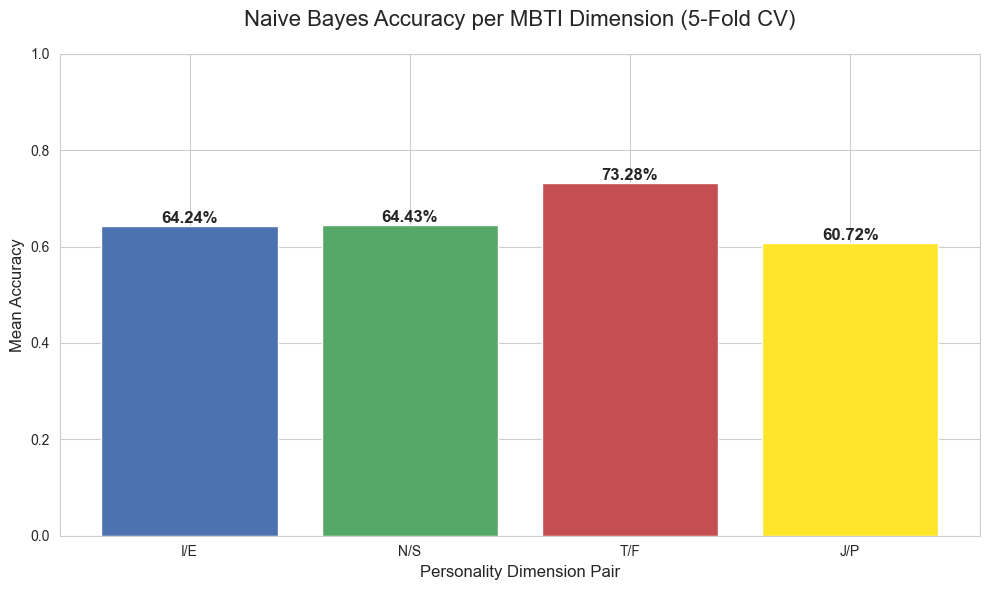


Average CV Accuracy: 65.67%
Average CV F1-Score: 0.6180


In [10]:
print("Starting Naive Bayes Training with 5-Fold Cross-Validation...")
dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
results = {}
f1_scores = []

# Set up 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Set a nice style for the plots
sns.set_style("whitegrid")

for trait1, trait2 in dimensions:
    print(f"\nProcessing {trait1} vs {trait2}")
    
    # Create binary labels
    y_binary = np.array([1 if trait2 in label else 0 for label in y])
    
    # Create pipeline with upsampling and classifier
    # This ensures upsampling happens inside each fold
    pipeline = ImbPipeline([
        ('sampler', RandomOverSampler(random_state=42)),
        ('classifier', MultinomialNB(alpha=5.0))
    ])
    
    # Perform 5-fold cross-validation
    cv_scores = cross_val_score(pipeline, X, y_binary, cv=cv, scoring='accuracy')
    cv_f1_scores = cross_val_score(pipeline, X, y_binary, cv=cv, scoring='f1_macro')
    
    # Calculate mean and std
    mean_acc = cv_scores.mean()
    std_acc = cv_scores.std()
    mean_f1 = cv_f1_scores.mean()
    std_f1 = cv_f1_scores.std()
    
    results[f"{trait1}/{trait2}"] = mean_acc
    f1_scores.append(mean_f1)
    
    print(f"   CV Accuracy: {mean_acc:.2%} (+/- {std_acc:.2%})")
    print(f"   CV F1-Score: {mean_f1:.4f} (+/- {std_f1:.4f})")
    print(f"   Individual fold accuracies: {[f'{score:.2%}' for score in cv_scores]}")
    
    # Optional: Train on full dataset for confusion matrix visualization
    pipeline.fit(X, y_binary)
    y_pred_full = pipeline.predict(X)
    conf_mat = confusion_matrix(y_binary, y_pred_full)
    print(f"   Confusion Matrix (full data):\n{conf_mat}")

# Plotting the results
print("\nGenerating Bar Graph...")
plt.figure(figsize=(10, 6))
keys = list(results.keys())
values = list(results.values())

# Create bars
bars = plt.bar(keys, values, color=['#4c72b0', '#55a868', '#c44e52', "#ffe62a"])

# Add title and labels
plt.title('Naive Bayes Accuracy per MBTI Dimension (5-Fold CV)', fontsize=16, pad=20)
plt.xlabel('Personality Dimension Pair', fontsize=12)
plt.ylabel('Mean Accuracy', fontsize=12)
plt.ylim(0, 1.0)

# Add percentage numbers on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height,
             f'{height:.2%}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Final statistics
avg_accuracy = sum(results.values()) / len(results)
avg_f1 = sum(f1_scores) / len(f1_scores)

print(f"\nAverage CV Accuracy: {avg_accuracy:.2%}")
print(f"Average CV F1-Score: {avg_f1:.4f}")

## 9 - Observations and Limitations

**N vs S Dimension Challenge:**
- Consistently shows lower F1 score across all approaches
- Root causes:
  - Severe class imbalance in dataset (more N types than S types)
  - Subtle linguistic differences between N and S traits
  - N/S distinction may be less expressed in written text
- Even with upsampling, performance gap persists
- Future improvements could include:
  - More sophisticated sampling techniques (SMOTE)
  - Feature engineering specific to N/S traits
  - Ensemble methods combining multiple models
  - Additional data collection for S types

**General Limitations:**
- MBTI validity debate: psychological reliability concerns
- Self-reported types may be inaccurate
- Text posts may not fully capture personality
- Dataset bias (online forum users may not represent general population)